# BuildingsBench-faithful load forecasting study — canonical models, one notebook

Trains + evaluates **21 models** (3 official BuildingsBench persistence baselines; LSTM, GRU;
XGBoost, LightGBM; 7 canonical published Transformer/linear architectures — PatchTST,
iTransformer, TimeXer, DLinear, Informer, Autoformer, Crossformer; the paper's **own**
pretrained model family, Transformer-S/M/L (Gaussian); and 4 novel architectures grounded in
post-BuildingsBench literature — TFTLite, xLSTM, SpectraMix, Mamba, see below) across
**2 conditions** (no-weather / +weather), on a compute-bounded subsample of the official
Buildings-900K pretraining corpus, evaluated on **both** the official simulated test set and 7
real-building datasets — plus **weather-value analyses** (extreme days, longer horizons,
sensitivity gating) and **dataset EDA figures**, all persisted to Drive.

All logic lives in the `bblab/` package (cloned from this repo below) — this notebook is a thin,
readable run log. Preprocessing (Box-Cox load transform, per-channel weather StandardScaler,
linearly-scaled calendar features, the confirmed 7-channel weather order) is sourced directly
from the official [BuildingsBench repo](https://github.com/NatLabRockies/BuildingsBench) and the
public `oedi-data-lake` S3 bucket it publishes to — not a from-scratch reimplementation.

### Metrics (paper-comparable)
Headline NRMSE/NMAE/CRPS use the paper's **published aggregation**: the **median across
per-building values** (their `evaluation/aggregate.py` `return_aggregate_median`, used by
`zero_shot.py` for every benchmark table). Per-building NRMSE/NMAE are CV(RMSE)-style
(normalized by each building's own mean load); CRPS uses the paper's own **inverse-Box-Cox
Gaussian approximation** (in kWh). A pooled/global view (`*_pooled` — the formula their
`pretrain.py` uses to monitor validation; tail-sensitive, reads much higher) is kept as a
secondary column, not for paper comparison. Every trained model's **compute budget** (params,
epochs, train/eval wall time, GPU, peak memory) is recorded per row in `sim_results_v4.csv` on
Drive, next to the weights in `results/weights_v2/`.

### What changed vs. the previous draft of this study
- Dropped 5 homegrown architectures in favor of the field's standard published baselines, and
  added the paper's own Transformer-S/M/L (Gaussian) architecture as a direct comparison point
  (faithful port of `buildings_bench/models/transformers.py`: encoder-decoder `nn.Transformer`,
  teacher forcing at train time, autoregressive greedy decoding at inference — same shared
  train/eval loop as every other model here, no separate code path to maintain).
- Fixed: unnormalized calendar features in real-building eval, a crashed results cell
  (`PERBUILDING_REAL_DIR` NameError), single-fixed-window validation, a silently zero-filled
  corrupt training building, missing multiple-comparison correction on significance tests, and
  a mixed-units CRPS (kWh mean with Box-Cox sigma).
- Validation now matches the paper's actual split (temporal holdout of the last 2 weeks of the
  year, amy2018-release buildings only) instead of an arbitrary building-level carve-out from
  the training subsample — see the Data section below.
- Calendar encoding corrected to match the paper exactly (linear-scaled day-of-year/day-of-week/
  hour-of-day, **not** sin/cos).
- Persistence baseline is now the paper's actual 3 variants (Average/CopyLastDay/CopyLastWeek),
  not a single custom "ensemble."
- Real-building evaluation runs a headline **no-weather** track (every real building) plus an
  optional **+weather** track (temperature+humidity, wherever the public bucket has it — no
  external fetching, so buildings without published weather simply aren't in that track).

### Novel architectures (`config.NOVEL_MODELS`)
Four new models grounded in post-2023 forecasting literature, aiming to beat the canonical
baselines above rather than just replicate them. All share the same `(yh, exo) -> (mu_n,
raw_scale, mean, std)` interface as every other model, so they drop straight into the existing
train/eval loop with no special-casing.
- **`tftlite`** — a compact Temporal Fusion Transformer (Lim et al. 2021): per-timestep Variable
  Selection Networks (Gated Residual Network-weighted softmax over each input channel) feeding
  an LSTM encoder-decoder, a static enrichment GRN, then causal self-attention over the full
  history+horizon. Tests whether learned per-feature gating beats treating all exogenous inputs
  uniformly.
- **`xlstm`** — Beck et al. 2024's xLSTM sLSTM cell (exponential input/forget gates with a
  log-space stabilizer state, replacing the sigmoid gates of a vanilla LSTM) applied over 24h
  patches (7 patches per 168h window, not raw hourly steps — keeps the sequential recurrence
  affordable). Motivated by a 2024 building-heat-load benchmark where xLSTM outperformed both a
  Transformer and TFT.
- **`spectramix`** — TSMixer-style time-mixing + feature-mixing MLP blocks (Chen et al. 2023)
  over daily patches, blended with a FITS-style (Xu et al. 2024) complex-linear frequency-domain
  extrapolation branch (learned weights map the historical rFFT spectrum directly onto the
  extended-horizon spectrum), plus a differentiable heating/cooling degree-day term (learned
  balance points, ReLU degree-hours -> load correction) when weather is available. Tests whether
  a lightweight mixing+frequency approach with an explicit physical prior competes with
  attention-heavy models at a fraction of the parameter count.
- **`mamba`** — a from-scratch selective state-space scan (Gu & Dao 2023's S6: input-dependent
  discretization step size gating a diagonal linear recurrence) over daily patches, gated MLP
  around it in the Mamba block style. Tests the current "attention vs. selective-SSM" debate on
  this specific forecasting task.

### A note on compute
Transformer-L matches the paper's largest config (12+12 encoder/decoder layers, d_model=768,
~160M+ params) and is meaningfully heavier per epoch than everything else here. If you want to
skip it, run `config.ALL_MODELS.remove("transformer_l")` right after cell 2 (before cell 6) —
resumable checkpointing means it's otherwise fine to just let it span multiple Colab sessions.

### Resumability
Every long-running cell below writes to Google Drive and skips already-completed
(model, condition) pairs on re-run — safe to re-run this notebook after a Colab disconnect.
Trained weights are never re-trained once their checkpoint exists in `results/weights/`.


In [2]:
# === 1) Mount Drive, clone repo, install deps, GPU check ===
from google.colab import drive
drive.mount('/content/drive')

import os, subprocess, sys

REPO_URL = "https://github.com/nm-quan/Building-Bench-Future-Works"
REPO_DIR = "/content/Building-Bench-Future-Works"
if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", f"{REPO_DIR}/requirements.txt"], check=True)

import torch
assert torch.cuda.is_available(), "No GPU. Runtime > Change runtime type > A100."
torch.set_float32_matmul_precision("high")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True
print("GPU:", torch.cuda.get_device_name(0))


Mounted at /content/drive
GPU: Tesla T4


In [3]:
# === 2) Imports + config ===
from bblab import config, data, models, train, metrics, weather_real
import torch, numpy as np, pandas as pd, pickle, os, csv, time

paths = config.Paths().makedirs()
print(f"BENCH={paths.BENCH}")
print(f"models ({len(config.ALL_MODELS)}): {config.ALL_MODELS}")
print(f"L={config.L} H={config.H}  EPOCHS={config.EPOCHS} PATIENCE={config.PATIENCE}  N_TRAIN_BUILDINGS={config.N_TRAIN_BUILDINGS}")


BENCH=/content/drive/MyDrive/quick/bench
models (21): ['persistence_avg', 'persistence_last_day', 'persistence_last_week', 'lstm', 'gru', 'patchtst', 'itransformer', 'timexer', 'dlinear', 'informer', 'autoformer', 'crossformer', 'transformer_s', 'transformer_m', 'transformer_l', 'xgboost', 'lightgbm', 'tftlite', 'xlstm', 'spectramix', 'mamba']
L=168 H=24  EPOCHS=200 PATIENCE=20  N_TRAIN_BUILDINGS=20000


## Data

Sources the official BuildingsBench transforms + a compute-bounded (~20k building) subsample of
Buildings-900K, the official held-out Buildings-900K-test simulated test set, and the 7
real-building datasets — all directly from the public `oedi-data-lake` S3 bucket. Cached to Drive
under `paths.BENCH` so re-running this notebook doesn't re-download/re-process from scratch.

**Chronological-sort fix (important)**: Buildings-900K parquet rows are **not stored
chronologically** — the official loader's own docstring warns about this and sorts by timestamp
in `__getitem__`. Earlier versions of this pipeline skipped that sort, so every simulated series
was temporally scrambled: persistence baselines read ~2× the paper's published values
(copy-last-day 81 vs the paper's 34.9; verified directly on a raw test parquet: 102→45 NRMSE for
one building after sorting) and trained models could only learn "predict the mean."
`data._fetch_puma_parquet` now sorts and asserts monotonic timestamps. Data caches move to
`*_v2` and weights to `weights_v2`: **all models retrain on the fixed data** (checkpoints
trained on scrambled series are meaningless). Raw S3 downloads on Drive remain valid — the
rebuild re-processes locally without re-downloading. Real-building CSVs were always sorted
(`sort_index`) and are unaffected.

**Validation** matches the official split exactly (`scripts/data_generation/create_index_files.py`):
a temporal holdout of the last 336h (2 weeks) of the year, on the amy2018-release buildings only
(a real chronological year -- unlike the tmy3 releases, which splice together a synthetic "typical"
year with no genuine chronological tail, and which the paper's own script never validates on).
`train.train()` samples training windows so they never cross into that holdout range for amy2018
buildings, and validates only within it -- not a same-corpus building-level carve-out.


In [4]:
# === 3) Official BuildingsBench transforms (Box-Cox load, per-channel weather StandardScaler) ===
transforms = data.download_official_transforms(paths)
load_transform = transforms["load"]
weather_transforms = transforms["weather"]
print("weather channels (confirmed order):", list(weather_transforms.keys()))


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.1.3 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PowerTransformer from version 1.1.3 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


weather channels (confirmed order): ['temperature', 'humidity', 'wind_speed', 'wind_direction', 'global_horizontal_radiation', 'direct_normal_radiation', 'diffuse_horizontal_radiation']


In [ ]:
# === 4) Build the training subsample (official weekly-sampled index file) + official simulated test set ===
torch.manual_seed(config.SEED); np.random.seed(config.SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"

print("building train cache (first run downloads from S3; cached on Drive afterward)...")
TR_raw = data.build_train_cache(paths, transforms, n_buildings=config.N_TRAIN_BUILDINGS, seed=config.SEED)
print(f"  TRAIN  N={TR_raw['N']}  T={TR_raw['T']}h  n_time={TR_raw['Ft']} n_weather={TR_raw['Fw']}")

print("building simulated test cache (official Buildings-900K-test, held out from training)...")
TE_SIM_raw = data.build_sim_test_cache(paths, transforms)
print(f"  SIM TEST  N={TE_SIM_raw['N']}  T={TE_SIM_raw['T']}h")

TR = train.to_device_cache(TR_raw, DEV)
TE_SIM = train.to_device_cache(TE_SIM_raw, DEV)


building train cache (first run downloads from S3; cached on Drive afterward)...
  [cache] 20000 buildings, T=8759h, dropped 0 non-finite series
  TRAIN  N=20000  T=8759h  n_time=3 n_weather=7
building simulated test cache (official Buildings-900K-test, held out from training)...
  [cache] 2928 buildings, T=8759h, dropped 0 non-finite series
  SIM TEST  N=2928  T=8759h


In [ ]:
# === 5) Load the 7 real-building datasets directly from the public S3 bucket (no separate data-prep notebook needed) ===
TE_REAL = data.load_real_buildings(paths)
n_com = sum(1 for b in TE_REAL if b["building_type"] > 0)
n_res = sum(1 for b in TE_REAL if b["building_type"] < 0)
print(f"REAL TEST  N={len(TE_REAL)}  com={n_com}  res={n_res}")


  [real] BDG-2: 611 buildings from 8 files, dropped 1 empty/unparseable files
  [real] Borealis: 15 buildings from 15 files
  [real] Electricity: 359 buildings from 4 files
  [real] IDEAL: 219 buildings from 350 files
  [real] LCL: 713 buildings from 1405 files
  [real] SMART: 5 buildings from 11 files
  [real] Sceaux: 1 buildings from 4 files
REAL TEST  N=1923  com=970  res=953


In [ ]:
# === FIX: merge multi-year real-building files into one building (paste + run, then re-run cell 5, 8, 9) ===
from pathlib import Path
import pandas as pd
from bblab import data as _data

def load_real_buildings_fixed(paths, datasets=None, verbose=True):
    """One entry per NAMED building: files split across years (e.g. BDG-2's
    Bear_clean=2016.csv / Bear_clean=2017.csv both have a 'Bear_public_Orville'
    column -- same physical meter) are concatenated into ONE continuous series,
    matching the official TorchBuildingDatasetsFromCSV.__iter__ exactly."""
    datasets = datasets or _data.REAL_DATASETS
    meta = _data.load_benchmark_toml(paths)
    out = []
    for ds in datasets:
        try:
            names = _data._s3_ls(f"{_data.S3_PREFIX}/{ds}/")
        except Exception as e:
            if verbose:
                print(f"  [warn] cannot list {ds}: {e}")
            continue
        csvs = [n for n in names if n.endswith(".csv") and "_clean=" in n]
        n_dropped_empty = 0
        per_building = {}
        for name in csvs:
            local = Path(paths.RAW_CACHE_DIR) / "real" / ds / name
            _data._s3_cp(f"{_data.S3_PREFIX}/{ds}/{name}", str(local))
            df = pd.read_csv(local)
            ts_col = _data._real_timestamp_col(df)
            data_cols = [c for c in df.columns if c != ts_col] if ts_col is not None else []
            if ts_col is None or not data_cols:
                n_dropped_empty += 1
                continue
            idx = pd.to_datetime(df[ts_col], errors="coerce")
            stem = name.split(".csv")[0]
            site = stem.split("_clean=")[0]
            try:
                year = int(stem.split("_clean=")[1])
            except (IndexError, ValueError):
                year = 0
            multi = len(data_cols) > 1
            for col in data_cols:
                vals = pd.to_numeric(df[col], errors="coerce").values
                series = pd.Series(vals, index=idx)
                series = series[series.index.notna()]
                series = series[np.isfinite(series.values)]
                if series.empty:
                    continue
                key = (site, col if multi else None)
                per_building.setdefault(key, []).append((year, series))

        n_added = 0
        for (site, col), year_series in per_building.items():
            year_series.sort(key=lambda ys: ys[0])
            series = pd.concat([s for _, s in year_series]).sort_index()
            bt = _data._building_type_for(ds, site, meta)
            bid = f"{ds}:{site}:{col}" if col is not None else f"{ds}:{site}"
            out.append({"building_id": bid, "building_type": bt, "series": series})
            n_added += 1
        if verbose:
            dropped_note = f", dropped {n_dropped_empty} empty/unparseable files" if n_dropped_empty else ""
            print(f"  [real] {ds}: {n_added} buildings from {len(csvs)} files{dropped_note}")
    return out

def weather_for_building_fixed(building_id, wcache):
    parts = building_id.split(":")
    dataset, site = parts[0], parts[1]
    if dataset == "BDG-2":
        return wcache.get(dataset, {}).get(site)
    return wcache.get(dataset, {}).get("default")

_data.load_real_buildings = load_real_buildings_fixed
_data.weather_for_building = weather_for_building_fixed
print("patched: data.load_real_buildings, data.weather_for_building")

patched: data.load_real_buildings, data.weather_for_building


## Dataset EDA

Publication figures for the data itself (saved to `results/figures/` on Drive): mean-normalized
load heatmaps (day-of-year x hour-of-day, Com vs Res), median daily profiles with IQR bands, a
weather-load correlation heatmap ("is there weather signal in this data at all" — worth showing
next to the weather-ablation results), and a per-dataset overview of the real-building eval set.


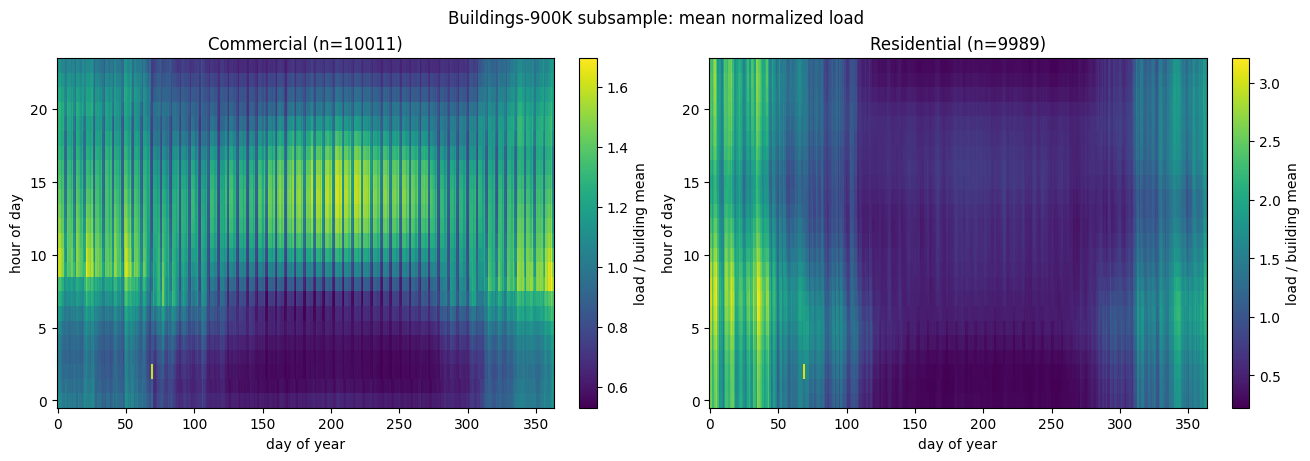

/content/drive/MyDrive/quick/bench/results/figures/load_heatmap.png


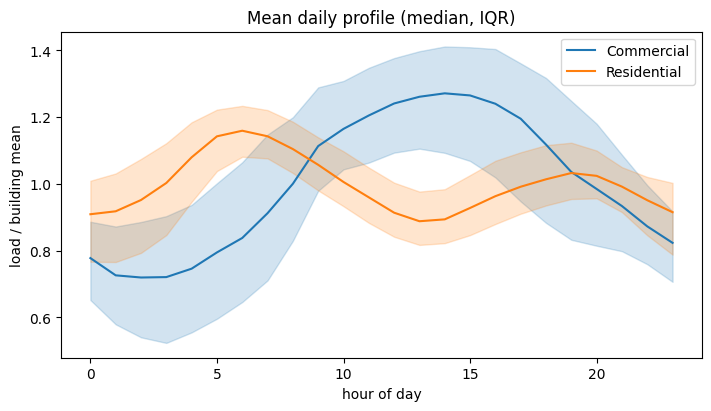

/content/drive/MyDrive/quick/bench/results/figures/daily_profiles.png


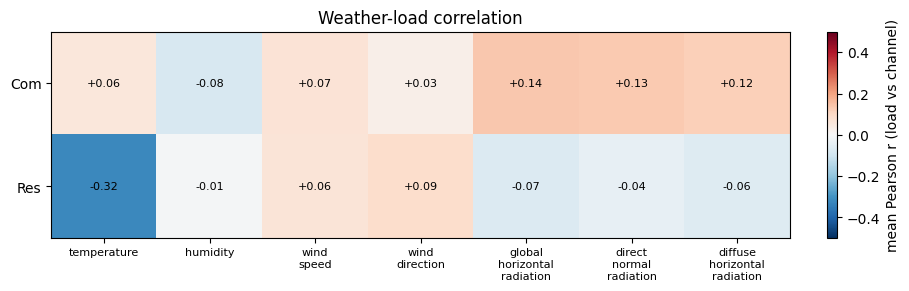

/content/drive/MyDrive/quick/bench/results/figures/weather_load_corr.png


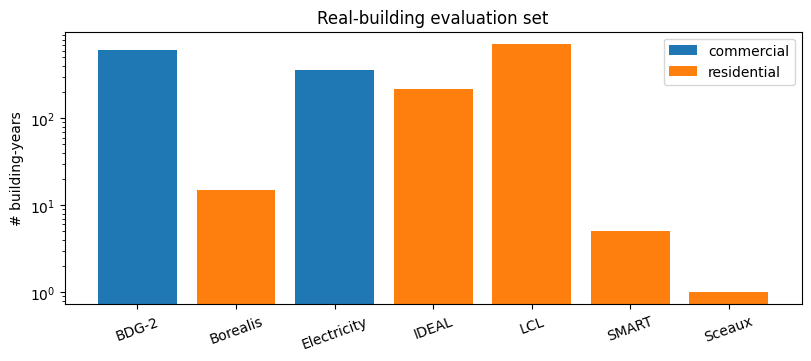

/content/drive/MyDrive/quick/bench/results/figures/real_overview.png


,dataset,buildings,com,res,median_hours,median_mean_kw
0,BDG-2,611,611,0,17544,61.646
1,Borealis,15,0,15,5555,0.731
2,Electricity,359,359,0,26304,131.431
3,IDEAL,219,0,219,5007,0.328
4,LCL,713,0,713,13909,0.166
5,SMART,5,0,5,25919,0.822
6,Sceaux,1,0,1,34223,1.083


In [ ]:
# === 5b) Dataset EDA: load heatmaps, daily profiles, weather-load correlation, real overview ===
# All figures are saved to paths.FIGURES_DIR on Drive (200dpi PNG, manuscript-ready).
from bblab import eda

print(eda.load_heatmaps(TR_raw, paths))
print(eda.daily_profiles(TR_raw, paths))
print(eda.weather_load_correlation(TR_raw, paths))
overview, fig_path = eda.real_dataset_overview(TE_REAL, paths)
print(fig_path)
overview


## Train all models x both conditions (resumable)

`ALL_MODELS` = 3 persistence baselines (closed-form, 0 params) + LSTM/GRU/DLinear/PatchTST/
iTransformer/TimeXer/Informer/Autoformer/Crossformer (trained) + the paper's own
Transformer-S/M/L (Gaussian) (trained, teacher forcing) + XGBoost/LightGBM (fit) +
TFTLite/xLSTM/SpectraMix/Mamba (trained, `config.NOVEL_MODELS`). Skips any (model, condition)
pair already present in `sim_results_v4.csv` — safe to re-run after a disconnect. **Never
retrains a model whose checkpoint already exists on Drive** (`results/weights_v2/{model}_{cond}.pt`
/ `.pkl`): those pairs only re-run the ~15s evaluation, so metric-definition changes never
repeat any training. Each row also records the compute budget (epochs, train/eval wall time,
GPU, peak memory).

**Capacity floor**: every transformer-family baseline (PatchTST, iTransformer, TimeXer,
Informer, Autoformer, Crossformer, TFTLite) is sized to **≥7M parameters** in both conditions
(`models.MIN_TRANSFORMER_PARAMS`), so capacity is never the reason an architecture loses to
persistence. The paper's own Transformer-S stays at its published (smaller) config on purpose —
its value is exactness, and M/L already exceed the floor. Checkpoints saved under older
(smaller) configs are detected by shape mismatch and retrained automatically; their stale rows
are dropped from the results CSV. This is the long-running cell; expect several hours (more
with Transformer-L included) for a from-scratch sweep on an A100.


In [ ]:
# === 6) Train all models x both conditions (resumable) ===
train.run_training_sweep(config.ALL_MODELS, config.CONDITIONS, TR, TE_SIM, DEV, load_transform, paths,
                          reset=False, log=True)


  done 16s  Com NRMSE=33.508  Res NRMSE=55.461  (pooled 51.549/64.192)

  done 16s  Com NRMSE=33.508  Res NRMSE=55.461  (pooled 51.549/64.192)

  done 13s  Com NRMSE=35.059  Res NRMSE=58.908  (pooled 55.094/63.713)

  done 13s  Com NRMSE=35.059  Res NRMSE=58.908  (pooled 55.094/63.713)

  done 12s  Com NRMSE=32.793  Res NRMSE=74.568  (pooled 53.002/86.519)

  done 13s  Com NRMSE=32.793  Res NRMSE=74.568  (pooled 53.002/86.519)

train lstm/A (131,472p, amp=False)...
    ep000 val=1.5708 best=1.5708 bad=0
    ep010 val=1.1451 best=1.1451 bad=0
    ep020 val=1.1027 best=1.0870 bad=1
    ep030 val=1.0610 best=1.0479 bad=5
    ep040 val=1.0206 best=1.0206 bad=0
    ep050 val=1.0025 best=0.9941 bad=2
    ep060 val=0.9852 best=0.9783 bad=1
    ep070 val=0.9690 best=0.9675 bad=3
    ep080 val=0.9488 best=0.9488 bad=0
    ep090 val=0.9496 best=0.9451 bad=6
    ep100 val=0.9381 best=0.9329 bad=8
    ep110 val=0.9381 best=0.9264 bad=1
    ep120 val=0.9325 best=0.9156 bad=6
    ep130 val=0.9297 be

KeyboardInterrupt: 

In [ ]:
# Train Crossformer only
train.run_training_sweep(["crossformer"], config.CONDITIONS, TR, TE_SIM, DEV, load_transform, paths, reset=False, log=True)

train crossformer/A (11,963,568p, amp=True)...
    ep000 val=1.0745 best=1.0745 bad=0
    ep010 val=0.8158 best=0.8138 bad=1
    ep020 val=0.7653 best=0.7653 bad=0
    ep030 val=0.7322 best=0.7322 bad=0
    ep040 val=0.7334 best=0.7127 bad=4
    ep050 val=0.7153 best=0.7001 bad=9
    ep060 val=0.6816 best=0.6816 bad=0
    ep070 val=0.7001 best=0.6662 bad=5
    ep080 val=0.7159 best=0.6662 bad=15
    early stop @ep85
  done 1673s  Com NRMSE=18.651  Res NRMSE=44.487  (pooled 32.447/47.468)

train crossformer/B (17,050,608p, amp=True)...
    ep000 val=1.0586 best=1.0586 bad=0
    ep010 val=0.5620 best=0.5620 bad=0
    ep020 val=0.4513 best=0.4513 bad=0
    ep030 val=0.3850 best=0.3850 bad=0
    ep040 val=0.3426 best=0.3426 bad=0
    ep050 val=0.3322 best=0.3192 bad=1
    ep060 val=0.2868 best=0.2868 bad=0
    ep070 val=0.2733 best=0.2571 bad=2
    ep080 val=0.2584 best=0.2411 bad=5
    ep090 val=0.2307 best=0.2307 bad=0
    ep100 val=0.2261 best=0.2130 bad=2
    ep110 val=0.2167 best=0.19

In [ ]:
# Train Novel Models only
train.run_training_sweep(config.NOVEL_MODELS, config.CONDITIONS, TR, TE_SIM, DEV, load_transform, paths, reset=False, log=True)

train tftlite/A (7,734,767p, amp=True)...
    ep000 val=1.2470 best=1.2470 bad=0
    ep010 val=0.8289 best=0.8289 bad=0
    ep020 val=0.7597 best=0.7597 bad=0
    ep030 val=0.7621 best=0.7299 bad=2
    ep040 val=0.7449 best=0.7133 bad=6
    ep050 val=0.7392 best=0.7052 bad=1
    ep060 val=0.7451 best=0.7052 bad=11
    ep070 val=0.7430 best=0.6756 bad=9
    ep080 val=0.6834 best=0.6756 bad=19
    ep090 val=0.6850 best=0.6459 bad=2
    ep100 val=0.6369 best=0.6369 bad=0
    ep110 val=0.6674 best=0.6369 bad=10
    ep120 val=0.6911 best=0.6369 bad=20
    early stop @ep120
  done 4229s  Com NRMSE=19.428  Res NRMSE=45.995  (pooled 33.079/48.643)

train tftlite/B (15,019,317p, amp=True)...
    ep000 val=1.0682 best=1.0682 bad=0
    ep010 val=0.4080 best=0.4080 bad=0
    ep020 val=0.3897 best=0.3076 bad=3
    ep030 val=0.2558 best=0.2519 bad=1
    ep040 val=0.2090 best=0.1761 bad=3
    ep050 val=0.1724 best=0.1339 bad=2
    ep060 val=0.1486 best=0.1011 bad=2
    ep070 val=0.0951 best=0.0488 ba

KeyboardInterrupt: 

In [ ]:
# Train TFTLite only
train.run_training_sweep(["tftlite"], config.CONDITIONS, TR, TE_SIM, DEV, load_transform, paths, reset=False, log=True)

In [ ]:
# Train XGBoost and LightGBM only
train.run_training_sweep(["xgboost", "lightgbm"], config.CONDITIONS, TR, TE_SIM, DEV, load_transform, paths, reset=False, log=True)

skip xgboost/A
skip xgboost/B
skip lightgbm/A
  done 172s  Com NRMSE=20.39  Res NRMSE=45.5  (pooled 37.237/48.675)

DONE -> /content/drive/MyDrive/quick/bench/results/sim_results_v4.csv


## Simulated-test results

Two views of the same evaluation pass:
- **Headline (paper-comparable)**: the **median across per-building values** — exactly how the
  published BuildingsBench tables aggregate (`evaluation/aggregate.py`'s
  `return_aggregate_median`, called by `zero_shot.py` for both the simulated and real-building
  benchmarks). Per-building NRMSE/NMAE are CV(RMSE)-style (normalized by that building's own
  mean load); CRPS uses the paper's inverse-Box-Cox Gaussian approximation, in kWh. These are
  the `com_nrmse`/`res_nrmse`/... columns in `sim_results_v4.csv`.
- **Pooled** (`*_pooled` columns): one pooled error over all windows of all buildings per group —
  the formula the paper's `pretrain.py` uses to monitor validation during pretraining.
  Tail-sensitive (dominated by the worst buildings), so it reads much higher than the median.
  Secondary/diagnostic view only — do **not** compare it to the paper's tables.

The bootstrap-CI table below and the Wilcoxon (Holm-Bonferroni) / Friedman + Nemenyi tests all
operate on the matched per-building arrays, mirroring the paper's bootstrapped-CI methodology.


In [ ]:
# === 7) Simulated-test results: median [95% bootstrap CI], Holm-Bonferroni-corrected significance vs persistence_avg ===
def load_pb(path):
    try:
        return pickle.load(open(path, "rb"))
    except FileNotFoundError:
        return None

BASELINE = config.BASELINE_MODEL
for cond in ["A", "B"]:
    print(f"-- Condition {cond} ({'no weather' if cond == 'A' else '+weather'}) --")
    base_pb = load_pb(f"{paths.PERBUILDING_SIM_DIR}/{BASELINE}_{cond}.pkl")
    pvals = {}
    for name in config.ALL_MODELS:
        pb = load_pb(f"{paths.PERBUILDING_SIM_DIR}/{name}_{cond}.pkl")
        if pb is None:
            continue
        vals = pb["_nrmse"][~pb["_is_res"]]
        med, lo, hi = metrics.bootstrap_median_ci(vals)
        note = ""
        if base_pb is not None and name != BASELINE:
            bvals = base_pb["_nrmse"][~base_pb["_is_res"]]
            p, better = metrics.paired_significance(vals, bvals)
            pvals[name] = p
            if better is True:
                note = f"  beats {BASELINE} (p={p:.1e}, uncorrected)"
            elif better is False and p == p and p < 0.05:
                note = f"  WORSE than {BASELINE} (p={p:.1e}, uncorrected)"
        print(f"  {name:24s} Com {med:6.2f} [{lo:5.2f},{hi:5.2f}]{note}")
    corrected = metrics.holm_bonferroni(pvals)
    winners = [k for k, (p, sig) in corrected.items() if sig]
    print(f"  Holm-Bonferroni-corrected significant wins vs {BASELINE}: {winners}\n")


-- Condition A (no weather) --
  persistence_avg          Com  33.51 [32.39,35.06]
  persistence_last_day     Com  35.06 [33.89,36.15]  WORSE than persistence_avg (p=3.8e-91, uncorrected)
  persistence_last_week    Com  32.79 [31.39,34.09]  beats persistence_avg (p=3.9e-06, uncorrected)
  lstm                     Com  21.17 [20.52,22.06]  beats persistence_avg (p=1.6e-176, uncorrected)
  gru                      Com  21.54 [20.86,22.64]  beats persistence_avg (p=1.3e-176, uncorrected)
  patchtst                 Com  18.36 [17.59,18.99]  beats persistence_avg (p=3.5e-181, uncorrected)
  itransformer             Com  19.07 [18.30,19.89]  beats persistence_avg (p=3.8e-181, uncorrected)
  timexer                  Com  18.45 [17.57,18.95]  beats persistence_avg (p=3.5e-181, uncorrected)
  dlinear                  Com  25.64 [24.98,26.13]  beats persistence_avg (p=6.7e-181, uncorrected)
  informer                 Com  18.59 [17.62,19.09]  beats persistence_avg (p=3.5e-181, uncorrected)
  cro

In [ ]:
# === 7b) Friedman + Nemenyi across the full model set (which models differ, with multiple-comparison control) ===
for cond in ["A", "B"]:
    pbs = {name: load_pb(f"{paths.PERBUILDING_SIM_DIR}/{name}_{cond}.pkl") for name in config.ALL_MODELS}
    pbs = {k: v for k, v in pbs.items() if v is not None}
    names = list(pbs.keys())
    arrs = [pbs[n]["_nrmse"][~pbs[n]["_is_res"]] for n in names]
    min_len = min(len(a) for a in arrs)
    mat = np.stack([a[:min_len] for a in arrs], axis=1)
    out = metrics.friedman_nemenyi(mat, names)
    ranked = sorted(out["avg_ranks"].items(), key=lambda kv: kv[1])
    print(f"cond {cond}: Friedman p={out['friedman_p']:.2e}  Nemenyi CD={out['nemenyi_critical_difference']:.3f}")
    print("  avg ranks (lower = better):", {k: round(v, 2) for k, v in ranked})
    print()


cond A: Friedman p=0.00e+00  Nemenyi CD=0.456
  avg ranks (lower = better): {'timexer': 2.1, 'patchtst': 2.29, 'informer': 2.9, 'crossformer': 3.19, 'itransformer': 4.58, 'lstm': 6.68, 'dlinear': 7.3, 'gru': 7.4, 'persistence_avg': 9.56, 'persistence_last_week': 9.82, 'persistence_last_day': 10.18}

cond B: Friedman p=0.00e+00  Nemenyi CD=0.456
  avg ranks (lower = better): {'crossformer': 1.58, 'timexer': 2.69, 'patchtst': 2.75, 'informer': 3.24, 'itransformer': 4.9, 'lstm': 6.8, 'gru': 7.18, 'dlinear': 7.31, 'persistence_avg': 9.57, 'persistence_last_week': 9.8, 'persistence_last_day': 10.18}



## Real-building evaluation

Two tracks:
1. **No-weather (headline)** — every real building, using the no-weather checkpoints. This is
   the primary real-world generalization result.
2. **+weather (temperature/humidity)** — the subset of real buildings whose dataset has published
   era5 weather on the public bucket (BuildingsBench's own real-eval only uses temperature; we
   include humidity too since it's already published alongside it). Buildings without published
   weather simply aren't in this track — no external fetching, no filled-in data.


In [ ]:
# === 8) Real-building evaluation: no-weather checkpoints (headline table, every real building) ===
def _r3(res, key):
    v = res.get(key, float("nan"))
    return round(v, 3) if v == v else ""

RFIELDS = ["model", "com_nrmse", "res_nrmse", "com_nmae", "res_nmae", "com_crps", "res_crps",
           "com_nrmse_pooled", "res_nrmse_pooled", "n_buildings", "sec"]

# Force re-evaluation: overwrite the CSV instead of appending
csv.DictWriter(open(paths.REAL_CSV, "w", newline=""), RFIELDS).writeheader()
rdone = set()

for name in config.ALL_MODELS:
    if name in rdone:
        print(f"skip {name} (real-eval)")
        continue
    t0 = time.time()
    try:
        if name in ("xgboost", "lightgbm"):
            mdl, sigma = pickle.load(open(f"{paths.WEIGHTS_DIR}/{name}_A.pkl", "rb"))
            res = train.evaluate_real_tree(mdl, sigma, TE_REAL, load_transform, weather_cache=None, stride=24)
        else:
            base = models.build(name, L=config.L, H=config.H, n_time=TR["Ft"], n_weather=TR["Fw"],
                                 use_weather=False, **models.MODEL_KW.get(name, {})).to(DEV)
            if models.count_params(base) > 0:
                sd_path = f"{paths.WEIGHTS_DIR}/{name}_A.pt"
                if not os.path.exists(sd_path):
                    print(f"  {name}: no no-weather checkpoint yet, skip")
                    continue
                base.load_state_dict(torch.load(sd_path, map_location=DEV))
            print(f"real-eval {name}...", flush=True)
            res = train.evaluate_real(base, TE_REAL, DEV, load_transform, weather_cache=None,
                                       amp=config.USE_AMP and name not in config.RNN_MODELS, stride=24)
        os.makedirs(paths.PERBUILDING_REAL_DIR, exist_ok=True)
        pickle.dump({k: res[k] for k in ("_nrmse", "_nmae", "_crps", "_is_res") if k in res},
                    open(f"{paths.PERBUILDING_REAL_DIR}/{name}.pkl", "wb"))
        row = {"model": name,
               "com_nrmse": _r3(res, "Com NRMSE"), "res_nrmse": _r3(res, "Res NRMSE"),
               "com_nmae": _r3(res, "Com NMAE"), "res_nmae": _r3(res, "Res NMAE"),
               "com_crps": _r3(res, "Com CRPS"), "res_crps": _r3(res, "Res CRPS"),
               "com_nrmse_pooled": _r3(res, "Com NRMSE pooled"), "res_nrmse_pooled": _r3(res, "Res NRMSE pooled"),
               "n_buildings": res.get("n_buildings", 0), "sec": round(time.time() - t0)}
        csv.DictWriter(open(paths.REAL_CSV, "a", newline=""), RFIELDS).writerow(row)
        print(f"  done {row['sec']}s  Com NRMSE={row['com_nrmse']}  Res NRMSE={row['res_nrmse']}  (n={row['n_buildings']})\n")
    except Exception as e:
        print(f"  FAILED {name}: {type(e).__name__}: {e}")
        import traceback; traceback.print_exc()
print("DONE ->", paths.REAL_CSV)

real-eval persistence_avg...
  done 213s  Com NRMSE=16.442  Res NRMSE=78.021  (n=1922)

real-eval persistence_last_day...
  done 213s  Com NRMSE=16.427  Res NRMSE=99.083  (n=1922)

real-eval persistence_last_week...
  done 212s  Com NRMSE=19.316  Res NRMSE=100.242  (n=1922)

real-eval lstm...
  done 213s  Com NRMSE=13.989  Res NRMSE=80.398  (n=1922)

real-eval gru...
  done 214s  Com NRMSE=14.176  Res NRMSE=80.408  (n=1922)

real-eval patchtst...
  done 215s  Com NRMSE=12.783  Res NRMSE=78.289  (n=1922)

real-eval itransformer...
  done 215s  Com NRMSE=12.675  Res NRMSE=78.892  (n=1922)

real-eval timexer...
  done 215s  Com NRMSE=12.572  Res NRMSE=77.811  (n=1922)

real-eval dlinear...
  done 214s  Com NRMSE=13.681  Res NRMSE=80.919  (n=1922)

real-eval informer...
  done 225s  Com NRMSE=13.201  Res NRMSE=79.074  (n=1922)

  autoformer: no no-weather checkpoint yet, skip
real-eval crossformer...
  done 220s  Com NRMSE=12.781  Res NRMSE=78.673  (n=1922)

  transformer_s: no no-weather 

Traceback (most recent call last):
  File "/tmp/ipykernel_1151/3686941928.py", line 20, in <cell line: 0>
    mdl, sigma = pickle.load(open(f"{paths.WEIGHTS_DIR}/{name}_A.pkl", "rb"))
                             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/quick/bench/results/weights_v2/xgboost_A.pkl'
Traceback (most recent call last):
  File "/tmp/ipykernel_1151/3686941928.py", line 20, in <cell line: 0>
    mdl, sigma = pickle.load(open(f"{paths.WEIGHTS_DIR}/{name}_A.pkl", "rb"))
                             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/quick/bench/results/weights_v2/lightgbm_A.pkl'


In [ ]:
import time
import os
import pickle
import csv
from bblab import train, config

# 1. Force train to generate the missing .pkl files in the current weights directory
print("Retraining tree models to generate missing weights...")
train.run_training_sweep(["xgboost", "lightgbm"], config.CONDITIONS, TR, TE_SIM, DEV, load_transform, paths, reset=True, log=True)

# 2. Evaluate on real dataset (Condition A - no weather)
for name in ["xgboost", "lightgbm"]:
    print(f"real-eval {name}...", flush=True)
    t0 = time.time()
    try:
        mdl, sigma = pickle.load(open(f"{paths.WEIGHTS_DIR}/{name}_A.pkl", "rb"))
        res = train.evaluate_real_tree(mdl, sigma, TE_REAL, load_transform, weather_cache=None, stride=24)

        os.makedirs(paths.PERBUILDING_REAL_DIR, exist_ok=True)
        pickle.dump({k: res[k] for k in ("_nrmse", "_nmae", "_crps", "_is_res") if k in res},
                    open(f"{paths.PERBUILDING_REAL_DIR}/{name}.pkl", "wb"))

        def _r3(res, key):
            v = res.get(key, float("nan"))
            return round(v, 3) if v == v else ""

        row = {"model": name,
               "com_nrmse": _r3(res, "Com NRMSE"), "res_nrmse": _r3(res, "Res NRMSE"),
               "com_nmae": _r3(res, "Com NMAE"), "res_nmae": _r3(res, "Res NMAE"),
               "com_crps": _r3(res, "Com CRPS"), "res_crps": _r3(res, "Res CRPS"),
               "com_nrmse_pooled": _r3(res, "Com NRMSE pooled"), "res_nrmse_pooled": _r3(res, "Res NRMSE pooled"),
               "n_buildings": res.get("n_buildings", 0), "sec": round(time.time() - t0)}

        csv.DictWriter(open(paths.REAL_CSV, "a", newline=""), RFIELDS).writerow(row)
        print(f"  done {row['sec']}s  Com NRMSE={row['com_nrmse']}  Res NRMSE={row['res_nrmse']}  (n={row['n_buildings']})\n")
    except Exception as e:
        print(f"  FAILED {name}: {type(e).__name__}: {e}")

Retraining tree models to generate missing weights...
  done 17s  Com NRMSE=22.314  Res NRMSE=47.405  (pooled 40.067/51.664)

  done 18s  Com NRMSE=21.687  Res NRMSE=46.555  (pooled 39.165/50.383)

  done 167s  Com NRMSE=21.004  Res NRMSE=46.883  (pooled 37.312/50.743)

  done 169s  Com NRMSE=20.39  Res NRMSE=45.5  (pooled 37.237/48.675)

DONE -> /content/drive/MyDrive/quick/bench/results/sim_results_v4.csv
real-eval xgboost...
  done 215s  Com NRMSE=14.167  Res NRMSE=79.632  (n=1922)

real-eval lightgbm...
  done 244s  Com NRMSE=13.561  Res NRMSE=79.534  (n=1922)



## Final comparison: no-weather vs +weather on real buildings

Side-by-side Com NRMSE, matched by model, on the subset of real buildings both tracks actually
evaluated (only buildings with published weather appear in the +weather column — see cell 9's
match count above for how many that is per dataset).


In [ ]:
# === 10) Final side-by-side: does +weather (temp/humidity) help on real buildings? ===
real_nw = pd.read_csv(paths.REAL_CSV).set_index("model")
real_w = pd.read_csv(paths.REAL_WEATHER_TEMP_CSV).set_index("model")
print(f"{'model':24s} {'no-weather':>12s} {'+weather':>12s} {'delta':>8s} {'matched':>8s}")
for name in config.ALL_MODELS:
    if name in real_nw.index and name in real_w.index:
        a = real_nw.loc[name, "com_nrmse"]
        b = real_w.loc[name, "com_nrmse"]
        matched = real_w.loc[name, "n_weather_matched"]
        tag = "  (weather helps)" if b < a else ""
        print(f"{name:24s} {a:12.3f} {b:12.3f} {b - a:+8.3f} {matched:8.0f}{tag}")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/quick/bench/results/real_weather_temp_results.csv'

## Weather-value analyses (the contribution layer)

Three analyses that turn "we re-benchmarked carefully" into a finding about *when and how much
weather inputs matter*. All run from saved checkpoints on Drive (no retraining), write resumable
CSVs to `results/analysis/`, and figures to `results/figures/`:

1. **Extreme days** — error bucketed by each building's own cold/mild/hot future-temperature
   deciles. Weather value concentrated on extreme days is invisible in annual averages.
2. **Longer horizons** — autoregressive rollout to 48h/72h. Copied-history information decays
   with horizon; known-future weather doesn't. Does the A-vs-B gap widen?
3. **Sensitivity gating** — per-channel knockout: which weather channels does each architecture
   actually use, and how much error does removing each one cost?


In [ ]:
# === 11) Weather-value 1: extreme-day evaluation (per-building cold/mild/hot temperature deciles) ===
# Averaging over a full year can hide weather value that's concentrated in exactly the days grid
# operators care about. Buckets every test window by the building's OWN future-temp deciles.
from bblab import analysis

EXT_CSV = f"{paths.ANALYSIS_DIR}/extreme_days.csv"
EFIELDS = ["model", "condition", "com_cold", "com_mild", "com_hot",
           "res_cold", "res_mild", "res_hot", "n_cold", "n_mild", "n_hot"]
if not os.path.exists(EXT_CSV):
    csv.DictWriter(open(EXT_CSV, "w", newline=""), EFIELDS).writeheader()
edone = {(r.model, r.condition) for _, r in pd.read_csv(EXT_CSV).iterrows()} if os.path.getsize(EXT_CSV) > 50 else set()

for name in config.ALL_MODELS:
    for cond, use_w in config.CONDITIONS.items():
        if (name, cond) in edone:
            print(f"skip {name}/{cond} (extreme-day)")
            continue
        fn = analysis.load_predict_fn(name, cond, use_w, TR["Ft"], TR["Fw"], paths, DEV)
        if fn is None:
            print(f"  {name}/{cond}: no checkpoint yet, skip")
            continue
        win = analysis.window_errors(fn, TE_SIM, DEV, use_w, load_transform, stride=24)
        ex = analysis.extreme_day_summary(win, TE_SIM)
        row = {"model": name, "condition": cond,
               "com_cold": round(ex.get("Com cold", float("nan")), 3),
               "com_mild": round(ex.get("Com mild", float("nan")), 3),
               "com_hot": round(ex.get("Com hot", float("nan")), 3),
               "res_cold": round(ex.get("Res cold", float("nan")), 3),
               "res_mild": round(ex.get("Res mild", float("nan")), 3),
               "res_hot": round(ex.get("Res hot", float("nan")), 3),
               "n_cold": ex["n cold"], "n_mild": ex["n mild"], "n_hot": ex["n hot"]}
        csv.DictWriter(open(EXT_CSV, "a", newline=""), EFIELDS).writerow(row)
        print(f"  {name}/{cond}: Com cold/mild/hot = {row['com_cold']}/{row['com_mild']}/{row['com_hot']}")

# headline: does weather help MORE on extreme days than mild ones?
edf = pd.read_csv(EXT_CSV)
if {"A", "B"} <= set(edf["condition"]):
    piv = edf.pivot_table(index="model", columns="condition",
                          values=["com_cold", "com_mild", "com_hot"])
    print("\nB-A delta (negative = weather helps) per bucket:")
    for bucket in ("com_cold", "com_mild", "com_hot"):
        d = piv[(bucket, "B")] - piv[(bucket, "A")]
        print(f"  {bucket:9s} mean Δ={d.mean():+.3f}  (models helped: {(d < 0).sum()}/{len(d)})")


  persistence_avg/A: Com cold/mild/hot = 51.543/52.825/49.977
  persistence_avg/B: Com cold/mild/hot = 51.543/52.825/49.977
  persistence_last_day/A: Com cold/mild/hot = 53.597/57.723/52.74
  persistence_last_day/B: Com cold/mild/hot = 53.597/57.723/52.74
  persistence_last_week/A: Com cold/mild/hot = 49.262/53.133/53.07
  persistence_last_week/B: Com cold/mild/hot = 49.262/53.133/53.07
  lstm/A: Com cold/mild/hot = 41.677/38.974/38.888
  lstm/B: Com cold/mild/hot = 38.172/37.58/39.002
  gru/A: Com cold/mild/hot = 42.872/40.004/39.341
  gru/B: Com cold/mild/hot = 38.117/38.343/39.063
  patchtst/A: Com cold/mild/hot = 32.392/31.825/31.668
  patchtst/B: Com cold/mild/hot = 29.196/29.421/30.045
  itransformer/A: Com cold/mild/hot = 33.942/33.028/33.021
  itransformer/B: Com cold/mild/hot = 31.562/32.212/33.905
  timexer/A: Com cold/mild/hot = 31.514/31.547/31.305
  timexer/B: Com cold/mild/hot = 25.502/27.134/30.897
  dlinear/A: Com cold/mild/hot = 39.652/41.073/39.248
  dlinear/B: Com co

In [ ]:
# === 12) Weather-value 2: autoregressive horizon rollout to 72h (A vs B) ===
# Feed each model's own 24h forecast back as history to reach 48h/72h. If known-future weather
# has value, the A-vs-B gap should WIDEN with horizon (persistence-copied information decays,
# weather doesn't). h1-24 reproduces the standard eval as a sanity anchor.
from bblab import analysis

ROLL_CSV = f"{paths.ANALYSIS_DIR}/rollout_horizons.csv"
segs = [f"h{24*k+1}-{24*(k+1)}" for k in range(config.ROLLOUT_STEPS)]
LFIELDS = ["model", "condition"] + [f"com_{s}" for s in segs] + [f"res_{s}" for s in segs]
if not os.path.exists(ROLL_CSV):
    csv.DictWriter(open(ROLL_CSV, "w", newline=""), LFIELDS).writeheader()
ldone = {(r.model, r.condition) for _, r in pd.read_csv(ROLL_CSV).iterrows()} if os.path.getsize(ROLL_CSV) > 50 else set()

for name in config.ALL_MODELS:
    for cond, use_w in config.CONDITIONS.items():
        if (name, cond) in ldone:
            print(f"skip {name}/{cond} (rollout)")
            continue
        fn = analysis.load_predict_fn(name, cond, use_w, TR["Ft"], TR["Fw"], paths, DEV)
        if fn is None:
            print(f"  {name}/{cond}: no checkpoint yet, skip")
            continue
        ro = analysis.rollout_eval(fn, TE_SIM, DEV, use_w, load_transform, stride=168)
        row = {"model": name, "condition": cond}
        for s in segs:
            row[f"com_{s}"] = round(ro[s]["Com"], 3)
            row[f"res_{s}"] = round(ro[s]["Res"], 3)
        csv.DictWriter(open(ROLL_CSV, "a", newline=""), LFIELDS).writerow(row)
        print(f"  {name}/{cond}: Com " + "  ".join(f"{s}={row[f'com_{s}']}" for s in segs))

# does the weather advantage grow with horizon?
rdf = pd.read_csv(ROLL_CSV)
if {"A", "B"} <= set(rdf["condition"]):
    piv = rdf.pivot_table(index="model", columns="condition", values=[f"com_{s}" for s in segs])
    print("\nB-A delta by horizon (negative = weather helps; watch whether it grows):")
    for s in segs:
        d = piv[(f"com_{s}", "B")] - piv[(f"com_{s}", "A")]
        print(f"  {s:8s} mean Δ={d.mean():+.3f}  (models improving with weather: {(d < 0).sum()}/{len(d)})")


  persistence_avg/A: Com h1-24=46.554  h25-48=49.992  h49-72=53.239
  persistence_avg/B: Com h1-24=46.554  h25-48=49.992  h49-72=53.239
  persistence_last_day/A: Com h1-24=81.195  h25-48=85.316  h49-72=85.1
  persistence_last_day/B: Com h1-24=81.195  h25-48=85.316  h49-72=85.1
  persistence_last_week/A: Com h1-24=51.087  h25-48=50.343  h49-72=50.966
  persistence_last_week/B: Com h1-24=51.087  h25-48=50.343  h49-72=50.966
  lstm/A: Com h1-24=42.961  h25-48=45.803  h49-72=48.266
  lstm/B: Com h1-24=43.315  h25-48=45.673  h49-72=47.553
  gru/A: Com h1-24=45.274  h25-48=47.577  h49-72=49.21
  gru/B: Com h1-24=44.167  h25-48=46.243  h49-72=47.799
  patchtst/A: Com h1-24=35.18  h25-48=39.23  h49-72=42.667
  patchtst/B: Com h1-24=31.99  h25-48=36.958  h49-72=40.464
  itransformer/A: Com h1-24=35.896  h25-48=39.564  h49-72=42.709
  itransformer/B: Com h1-24=35.239  h25-48=36.978  h49-72=40.075
  timexer/A: Com h1-24=33.85  h25-48=38.344  h49-72=41.981
  timexer/B: Com h1-24=31.117  h25-48=34.

  lstm: base=61.811  temp ΔNRMSE=+0.002
  gru: base=62.184  temp ΔNRMSE=+0.082
  patchtst: base=48.786  temp ΔNRMSE=+0.968
  itransformer: base=54.468  temp ΔNRMSE=+0.000
  timexer: base=47.362  temp ΔNRMSE=+15.662
  dlinear: base=59.243  temp ΔNRMSE=+0.484
  informer: base=51.278  temp ΔNRMSE=-0.081
  autoformer/B: no checkpoint yet, skip
  crossformer: base=43.06  temp ΔNRMSE=+40.205
  transformer_s/B: no checkpoint yet, skip
  transformer_m/B: no checkpoint yet, skip
  transformer_l/B: no checkpoint yet, skip
  xgboost/B: no checkpoint yet, skip
  lightgbm/B: no checkpoint yet, skip
  tftlite/B: no checkpoint yet, skip
  xlstm/B: no checkpoint yet, skip
  spectramix/B: no checkpoint yet, skip
  mamba/B: no checkpoint yet, skip


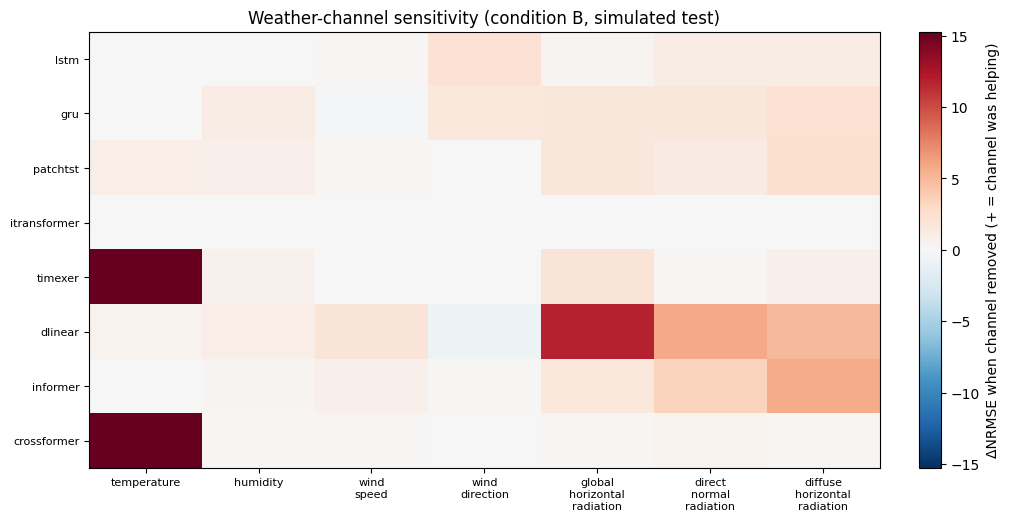

In [ ]:
# === 13) Weather-value 3: per-channel sensitivity gating (condition-B checkpoints) ===
# Knock out one weather channel at a time (-> training mean) over the forecast horizon and
# measure prediction movement + NRMSE degradation. Models x channels heatmap saved to Drive.
from bblab import analysis
import matplotlib.pyplot as plt

SENS_CSV = f"{paths.ANALYSIS_DIR}/weather_sensitivity.csv"
SFIELDS = ["model", "base_nrmse"] + [f"{c}_dnrmse" for c in config.WEATHER_COLS] + [f"{c}_dpred" for c in config.WEATHER_COLS]
if not os.path.exists(SENS_CSV):
    csv.DictWriter(open(SENS_CSV, "w", newline=""), SFIELDS).writeheader()
sdone = set(pd.read_csv(SENS_CSV)["model"]) if os.path.getsize(SENS_CSV) > 50 else set()

for name in [m for m in config.ALL_MODELS if m not in config.PERSISTENCE_MODELS]:
    if name in sdone:
        print(f"skip {name} (sensitivity)")
        continue
    fn = analysis.load_predict_fn(name, "B", True, TR["Ft"], TR["Fw"], paths, DEV)
    if fn is None:
        print(f"  {name}/B: no checkpoint yet, skip")
        continue
    sens = analysis.weather_sensitivity(fn, TE_SIM, DEV, load_transform, n_windows=4096)
    row = {"model": name, "base_nrmse": round(sens["_base_nrmse"], 3)}
    for c in config.WEATHER_COLS:
        row[f"{c}_dnrmse"] = round(sens[c]["delta_nrmse"], 4)
        row[f"{c}_dpred"] = round(sens[c]["pred_delta_pct"], 3)
    csv.DictWriter(open(SENS_CSV, "a", newline=""), SFIELDS).writerow(row)
    print(f"  {name}: base={row['base_nrmse']}  temp ΔNRMSE={row['temperature_dnrmse']:+.3f}")

# heatmap: models x channels, NRMSE degradation when the channel is removed
sdf = pd.read_csv(SENS_CSV).set_index("model")
if len(sdf):
    mat = sdf[[f"{c}_dnrmse" for c in config.WEATHER_COLS]].values
    fig, ax = plt.subplots(figsize=(10, 0.45 * len(sdf) + 1.5), constrained_layout=True)
    vmax = max(1e-6, np.nanpercentile(np.abs(mat), 98))
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(config.N_WEATHER), [c.replace("_", "\n") for c in config.WEATHER_COLS], fontsize=8)
    ax.set_yticks(range(len(sdf)), sdf.index, fontsize=8)
    fig.colorbar(im, ax=ax, label="ΔNRMSE when channel removed (+ = channel was helping)")
    ax.set_title("Weather-channel sensitivity (condition B, simulated test)")
    fig.savefig(f"{paths.FIGURES_DIR}/sensitivity_heatmap.png", dpi=200)
    plt.show()


In [ ]:
# === 14) Compute budget: params, epochs, wall time, peak GPU memory (all persisted in sim_results_v4.csv on Drive) ===
budget = pd.read_csv(paths.SIM_CSV)
cols = ["model", "condition", "params", "epochs", "train_sec", "eval_sec", "peak_mem_gb", "gpu", "reused_ckpt"]
display(budget[cols].sort_values(["model", "condition"]).reset_index(drop=True))
total_h = budget["train_sec"].sum() / 3600
print(f"total training compute this file: {total_h:.2f} GPU-hours on {budget['gpu'].iloc[0] if len(budget) else '?'}")
print("NOTE: rows with reused_ckpt=True were trained in an earlier session; their train_sec/epochs")
print("are recorded in the results file of the session that trained them (v1/v2 files on Drive).")


,model,condition,params,epochs,train_sec,eval_sec,peak_mem_gb,gpu,reused_ckpt
0,crossformer,A,11963568,86,1633.3,39.4,13.00,NVIDIA A100-SXM4-40GB,False
1,crossformer,B,17050608,152,4124.6,58.7,15.32,NVIDIA A100-SXM4-40GB,False
2,dlinear,A,60640,104,370.4,16.2,1.03,NVIDIA A100-SXM4-40GB,False
3,dlinear,B,103648,135,493.8,16.5,1.19,NVIDIA A100-SXM4-40GB,False
4,gru,A,103344,160,841.9,21.4,2.08,NVIDIA A100-SXM4-40GB,False
5,gru,B,119472,200,1070.1,21.6,2.08,NVIDIA A100-SXM4-40GB,False
6,informer,A,8023344,123,2142.8,50.4,4.25,NVIDIA A100-SXM4-40GB,False
7,informer,B,8087856,200,3493.9,45.3,4.25,NVIDIA A100-SXM4-40GB,False
8,itransformer,A,8782896,81,657.5,20.8,1.38,NVIDIA A100-SXM4-40GB,False
9,itransformer,B,9388592,39,349.3,23.7,1.61,NVIDIA A100-SXM4-40GB,False


total training compute this file: 6.76 GPU-hours on NVIDIA A100-SXM4-40GB
NOTE: rows with reused_ckpt=True were trained in an earlier session; their train_sec/epochs
are recorded in the results file of the session that trained them (v1/v2 files on Drive).


Top 10 models based on average Com and Res NRMSE (Simulated Test):
1. crossformer (Cond B): Avg NRMSE = 27.508
2. timexer (Cond B): Avg NRMSE = 28.825
3. patchtst (Cond B): Avg NRMSE = 29.840
4. informer (Cond B): Avg NRMSE = 29.932
5. itransformer (Cond B): Avg NRMSE = 31.620
6. tftlite (Cond A): Avg NRMSE = 32.712
7. lightgbm (Cond B): Avg NRMSE = 32.945
8. lstm (Cond B): Avg NRMSE = 33.436
9. gru (Cond B): Avg NRMSE = 33.642
10. xgboost (Cond B): Avg NRMSE = 34.121

Gathering predictions for the top 10 models...


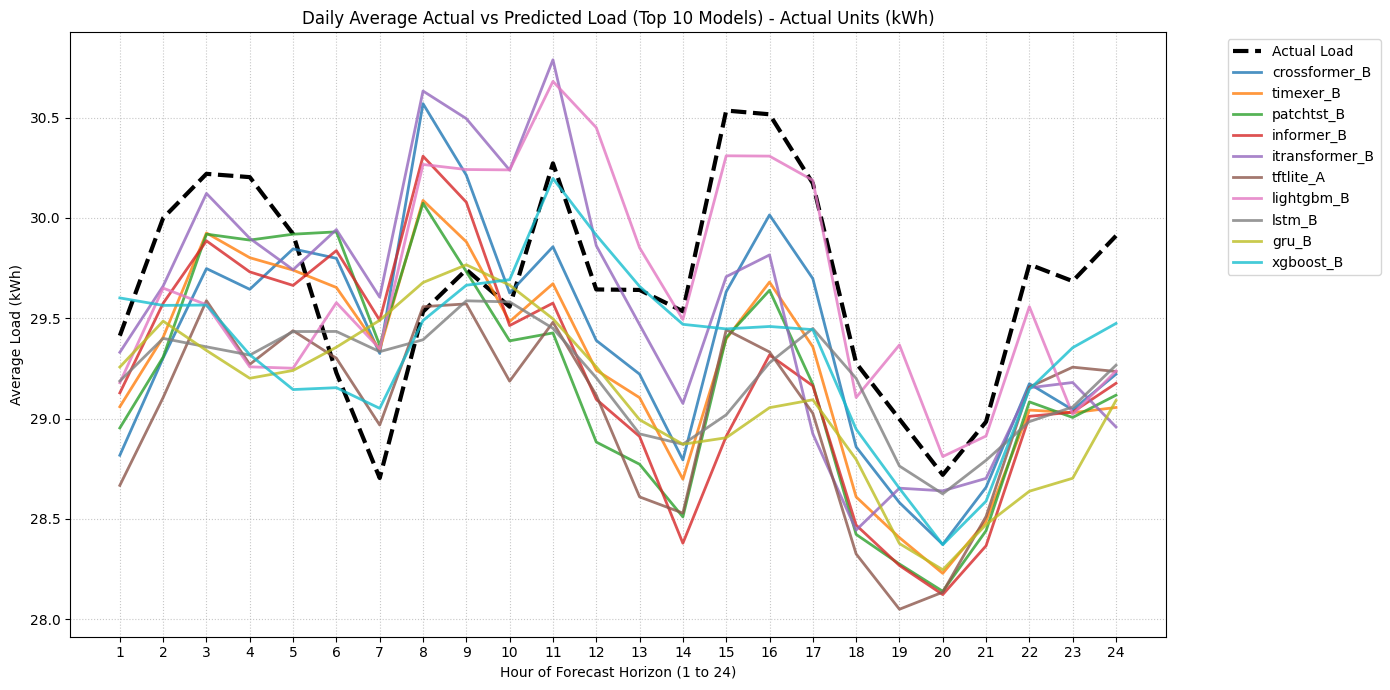

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from bblab import analysis, train

# 1. Load results and find top 10 best models based on average (Com + Res) NRMSE
df = pd.read_csv(paths.SIM_CSV)
df['avg_nrmse'] = (df['com_nrmse'] + df['res_nrmse']) / 2.0

# Sort by best average NRMSE and keep the best condition per model
best_models_df = df.sort_values('avg_nrmse').drop_duplicates(subset=['model']).head(10)

print("Top 10 models based on average Com and Res NRMSE (Simulated Test):")
for i, (_, row) in enumerate(best_models_df.iterrows(), 1):
    print(f"{i}. {row['model']} (Cond {row['condition']}): Avg NRMSE = {row['avg_nrmse']:.3f}")

top_models = best_models_df[['model', 'condition']].values.tolist()

# 2. Get predictions for a daily average (24h rollout)
torch.manual_seed(42)
N, T = TE_SIM['loads'].shape
bs = 1024  # sample a large batch of random windows

b = torch.randint(0, N, (bs,), device=DEV)
s = torch.randint(0, T - config.L - config.H, (bs,), device=DEV)

avg_preds = {}

print("\nGathering predictions for the top 10 models...")
for name, cond in top_models:
    use_w = config.CONDITIONS[cond]
    # Load the prediction function for the saved checkpoint
    fn = analysis.load_predict_fn(name, cond, use_w, TR["Ft"], TR["Fw"], paths, DEV)
    if fn is None:
        print(f"  Skipping {name}/{cond} (checkpoint not found)")
        continue

    # Gather the input windows
    yh, yf, exo, _ = train.gather(TE_SIM, b, s, use_w, load_transform, DEV)

    with torch.no_grad():
        with torch.autocast(device_type=("cuda" if "cuda" in DEV else "cpu"), enabled=config.USE_AMP):
            mean_pred = fn(yh, exo)

    # Convert back to tensor if it's numpy (e.g. XGBoost) so we can use load_transform.undo_transform
    if not torch.is_tensor(mean_pred):
        mean_pred = torch.tensor(mean_pred, device=DEV)

    # Undo the Box-Cox transformation to get actual kWh
    mean_pred_unnorm = load_transform.undo_transform(mean_pred)

    avg_preds[f"{name}_{cond}"] = mean_pred_unnorm.mean(dim=0).cpu().numpy()

# Get the actual un-transformed average load for the same batch
_, actual_yf, _, _ = train.gather(TE_SIM, b, s, False, load_transform, DEV)
actual_yf_unnorm = load_transform.undo_transform(actual_yf)
actual_avg = actual_yf_unnorm.mean(dim=0).cpu().numpy()

# 3. Plot Actual vs Predicted
plt.figure(figsize=(14, 7))
plt.plot(actual_avg, label='Actual Load', color='black', linewidth=3, linestyle='--')

for name_cond, pred in avg_preds.items():
    plt.plot(pred, label=name_cond, alpha=0.8, linewidth=2)

plt.title('Daily Average Actual vs Predicted Load (Top 10 Models) - Actual Units (kWh)')
plt.xlabel('Hour of Forecast Horizon (1 to 24)')
plt.ylabel('Average Load (kWh)')
plt.xticks(range(24), range(1, 25))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
pd.set_option("display.width", 120)

# === Simulated-test RPS (= CRPS, kWh, paper's inverse-Box-Cox approximation) ===
print("=== Simulated-test RPS ===")
sim = pd.read_csv(paths.SIM_CSV)
display(sim[["model", "condition", "com_nrmse", "com_crps", "res_nrmse", "res_crps"]]
        .rename(columns={"com_crps": "Com RPS", "res_crps": "Res RPS"})
        .sort_values(["model", "condition"]).reset_index(drop=True))

# === Real-building RPS: no-weather (headline, every real building) ===
print("\n=== Real-building RPS (no-weather) ===")
real = pd.read_csv(paths.REAL_CSV)
display(real[["model", "com_nrmse", "com_crps", "res_nrmse", "res_crps", "n_buildings"]]
        .rename(columns={"com_crps": "Com RPS", "res_crps": "Res RPS"})
        .sort_values("model").reset_index(drop=True))

# === Real-building RPS: +weather (subset with published weather) ===
print("\n=== Real-building RPS (+weather) ===")
real_w = pd.read_csv(paths.REAL_WEATHER_TEMP_CSV)
display(real_w[["model", "com_nrmse", "com_crps", "res_nrmse", "res_crps", "n_weather_matched"]]
        .rename(columns={"com_crps": "Com RPS", "res_crps": "Res RPS"})
        .sort_values("model").reset_index(drop=True))

=== Simulated-test RPS ===


,model,condition,com_nrmse,Com RPS,res_nrmse,Res RPS
0,crossformer,A,18.651,2.845,44.487,0.576
1,crossformer,B,14.682,2.180,40.334,0.499
2,dlinear,A,25.637,4.082,48.870,0.672
3,dlinear,B,25.264,4.074,48.061,0.647
4,gru,A,21.543,3.744,47.418,0.622
5,gru,B,20.945,3.674,46.339,0.597
6,informer,A,18.591,2.839,44.365,0.576
7,informer,B,17.544,2.614,42.321,0.547
8,itransformer,A,19.071,3.003,45.532,0.589
9,itransformer,B,18.703,3.099,44.538,0.584



=== Real-building RPS (no-weather) ===


,model,com_nrmse,Com RPS,res_nrmse,Res RPS,n_buildings
0,crossformer,12.781,4.883,78.673,0.068,1922
1,dlinear,13.681,5.472,80.919,0.076,1922
2,gru,14.176,5.651,80.408,0.071,1922
3,informer,13.201,5.061,79.074,0.069,1922
4,itransformer,12.675,4.959,78.892,0.069,1922
5,lstm,13.989,5.601,80.398,0.071,1922
6,patchtst,12.783,4.932,78.289,0.069,1922
7,persistence_avg,16.442,6.826,78.021,0.069,1922
8,persistence_last_day,16.427,NaN,99.083,NaN,1922
9,persistence_last_week,19.316,NaN,100.242,NaN,1922



=== Real-building RPS (+weather) ===


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/quick/bench/results/real_weather_temp_results.csv'

## Extended track: full 7-channel real weather (Open-Meteo ERA5)

The condition-B models are trained on 7 weather channels, but the BuildingsBench
bucket only publishes temperature (+humidity) for the real buildings, so the
earlier +weather real-building track froze 5 of 7 channels at the training mean.
This section fetches all 7 channels (wind speed/direction, GHI, DNI, DHI added)
from Open-Meteo's ERA5 archive -- the same reanalysis family the authors used --
for the **same locations, date ranges, and fixed local-standard-time offsets**
recovered verbatim from their `download_weather_era5.py`.

A **validation gate** compares our fetched temperature against the authors'
published era5 temperature per location (Pearson r > 0.95 at zero lag, mean
offset < 3 C); any location that fails (wrong coordinates, timezone, or units)
is dropped from the cache and never feeds the eval. The gate was verified
offline against real published data (passes aligned data; catches a 5 h timezone
slip -- reading out the exact lag -- and Kelvin-vs-Celsius unit errors).

**Self-contained:** run the cell below directly after cell 1 (repo clone/import)
-- it re-mounts nothing new, rebuilds transforms + real buildings from the Drive
cache, loads every condition-B checkpoint from `results/weights_v2/`, and needs
none of cells 2--14 to have run this session. First run fetches + caches the
weather to Drive (a few minutes); re-runs reuse the cache. No retraining.

In [ ]:
# === 15) EXTENDED: full 7-channel real-weather eval (self-contained; loads weights from Drive) ===
# Fetches ERA5 weather (all 7 channels) from Open-Meteo, validates it against the
# published temperature, then evaluates every +weather (condition B) checkpoint on
# the real buildings. Run directly after cell 1; needs none of cells 2-14.
import torch, numpy as np, pandas as pd, pickle, os, csv, time
from bblab import config, data, models, train, metrics, weather_real

paths = config.Paths().makedirs()
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print(f"BENCH={paths.BENCH}  DEV={DEV}")

# Rebuild the pieces the eval needs from the Drive cache (no training data required)
transforms = data.download_official_transforms(paths)
load_transform, weather_transforms = transforms["load"], transforms["weather"]
TE_REAL = data.load_real_buildings(paths)
n_time, n_weather = config.N_TIME, config.N_WEATHER
print(f"REAL TEST N={len(TE_REAL)}")

# Fetch + validate + cache the full 7-channel weather (fetches once, cached to Drive)
wcache_full = weather_real.build_full_weather_cache(paths, TE_REAL, validate=True, verbose=True)
print(f"{len(wcache_full)}/{len(TE_REAL)} real buildings have validated full weather\n")

# Evaluate every condition-B checkpoint against the full-weather real buildings
FFIELDS = ["model", "com_nrmse", "res_nrmse", "com_nmae", "res_nmae", "com_crps", "res_crps",
           "com_nrmse_pooled", "res_nrmse_pooled", "n_buildings", "n_weather_matched", "sec"]
FULL_CSV = paths.REAL_WEATHER_FULL_CSV
if not os.path.exists(FULL_CSV):
    csv.DictWriter(open(FULL_CSV, "w", newline=""), FFIELDS).writeheader()
fdone = {r.model for _, r in pd.read_csv(FULL_CSV).iterrows()} if os.path.getsize(FULL_CSV) > 50 else set()

def _r3(res, key):
    v = res.get(key, float("nan"))
    return round(v, 3) if v == v else ""

for name in [m for m in config.ALL_MODELS if m not in config.TREE_MODELS]:
    if name in fdone:
        print(f"skip {name} (full-weather real-eval)")
        continue
    t0 = time.time()
    try:
        base = models.build(name, L=config.L, H=config.H, n_time=n_time, n_weather=n_weather,
                            use_weather=True, **models.MODEL_KW.get(name, {})).to(DEV)
        if models.count_params(base) > 0:
            sd_path = f"{paths.WEIGHTS_DIR}/{name}_B.pt"
            if not os.path.exists(sd_path):
                print(f"  {name}: no +weather checkpoint yet, skip")
                continue
            base.load_state_dict(torch.load(sd_path, map_location=DEV))
        print(f"full-weather real-eval {name}...", flush=True)
        res = train.evaluate_real(base, TE_REAL, DEV, load_transform, weather_cache=wcache_full,
                                   weather_transforms=weather_transforms,
                                   amp=config.USE_AMP and name not in config.RNN_MODELS, stride=24)
        os.makedirs(paths.PERBUILDING_REAL_WEATHER_FULL_DIR, exist_ok=True)
        pickle.dump({k: res[k] for k in ("_nrmse", "_nmae", "_crps", "_is_res") if k in res},
                    open(f"{paths.PERBUILDING_REAL_WEATHER_FULL_DIR}/{name}.pkl", "wb"))
        row = {"model": name,
               "com_nrmse": _r3(res, "Com NRMSE"), "res_nrmse": _r3(res, "Res NRMSE"),
               "com_nmae": _r3(res, "Com NMAE"), "res_nmae": _r3(res, "Res NMAE"),
               "com_crps": _r3(res, "Com CRPS"), "res_crps": _r3(res, "Res CRPS"),
               "com_nrmse_pooled": _r3(res, "Com NRMSE pooled"), "res_nrmse_pooled": _r3(res, "Res NRMSE pooled"),
               "n_buildings": res.get("n_buildings", 0), "n_weather_matched": res.get("n_weather_matched", 0),
               "sec": round(time.time() - t0)}
        csv.DictWriter(open(FULL_CSV, "a", newline=""), FFIELDS).writerow(row)
        print(f"  done {row['sec']}s  Com NRMSE={row['com_nrmse']}  Res NRMSE={row['res_nrmse']}"
              f"  Com RPS={row['com_crps']}  (matched={row['n_weather_matched']})\n")
    except Exception as e:
        print(f"  FAILED {name}: {type(e).__name__}: {e}")
        import traceback; traceback.print_exc()
print("DONE ->", FULL_CSV)
pd.read_csv(FULL_CSV)


BENCH=/content/drive/MyDrive/quick/bench  DEV=cuda


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.1.3 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PowerTransformer from version 1.1.3 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


  [real] BDG-2: 611 buildings from 8 files, dropped 1 empty/unparseable files
  [real] Borealis: 15 buildings from 15 files
  [real] Electricity: 359 buildings from 4 files
  [real] IDEAL: 219 buildings from 350 files
  [real] LCL: 713 buildings from 1405 files
  [real] SMART: 5 buildings from 11 files
  [real] Sceaux: 1 buildings from 4 files
REAL TEST N=1923
  [full-weather] fetching Bear (37.872,-122.259) 2015-12-31..2018-01-01 off=-8h ...
    [validate] PASS  r@lag0=0.9583  best_lag=0h  mean_off=1.055C  (n=17592h)
  [full-weather] fetching Borealis (43.475,-80.54) 2010-12-31..2013-01-01 off=-5h ...
    [validate] PASS  r@lag0=0.9931  best_lag=0h  mean_off=0.167C  (n=17592h)
  [full-weather] fetching Electricity (38.745,-9.15) 2011-01-01..2014-12-31 off=0h ...
    [validate] PASS  r@lag0=0.9909  best_lag=0h  mean_off=0.014C  (n=35064h)
  [full-weather] fetching Fox (33.416,-111.935) 2015-12-31..2018-01-01 off=-7h ...
    [validate] PASS  r@lag0=0.9911  best_lag=0h  mean_off=0.08C  (

In [ ]:
# === 16) Full-weather vs temp-only vs no-weather on real buildings (side-by-side) ===
import pandas as pd, os
def _load(p):
    return pd.read_csv(p).set_index("model") if os.path.exists(p) and os.path.getsize(p) > 50 else None
nw   = _load(paths.REAL_CSV)                 # no weather
tw   = _load(paths.REAL_WEATHER_TEMP_CSV)    # temp+humidity only
fw   = _load(paths.REAL_WEATHER_FULL_CSV)    # full 7 channels
print(f"{'model':16s}{'no-wx':>9s}{'temp-wx':>9s}{'full-wx':>9s}{'full-nw':>9s}")
for name in config.ALL_MODELS:
    a = nw.loc[name, "com_nrmse"] if nw is not None and name in nw.index else float("nan")
    b = tw.loc[name, "com_nrmse"] if tw is not None and name in tw.index else float("nan")
    c = fw.loc[name, "com_nrmse"] if fw is not None and name in fw.index else float("nan")
    if c == c and a == a:
        print(f"{name:16s}{a:9.3f}{b:9.3f}{c:9.3f}{c-a:+9.3f}")
